# Mahalanobis Distance

**Understanding Covariance, Geometric Interpretation, and Bayesian Decision Theory**

In this tutorial, we will explore the **covariance matrix**, its geometric interpretation, and its critical role in **Bayesian Decision Theory**, particularly in the context of the **Mahalanobis Distance**. We will derive the mathematical properties of these concepts and illustrate them with Python code and visualizations.

*Resources:* Adapted from [Vision Dummy](https://www.visiondummy.com/2014/04/geometric-interpretation-covariance-matrix/), [SAS Blogs](https://blogs.sas.com/content/iml/2012/02/15/what-is-mahalanobis-distance.html), [Wikipedia](https://en.wikipedia.org/wiki/Mahalanobis_distance), and Chapter 2 of *Pattern Classification* by Duda, Hart, and Stork {cite}`Duda2000`.

---

## 1. Why Do We Need Mahalanobis Distance?

In many real-world applications, we deal with **multivariate data** where features are often correlated and have different scales. While the **Euclidean distance** ($\|\mathbf{x} - \mathbf{y}\|_2$) is a common choice for measuring distances, it has a significant limitation: it assumes that all features are **uncorrelated** and have the **same variance**. This assumption rarely holds in practice.

Consider a dataset where one feature is measured in meters and another in kilometers. Euclidean distance would disproportionately weigh the feature with larger values. Similarly, if features are correlated, the "shape" of the data distribution is an ellipsoid rather than a sphere. Euclidean distance fails to account for this underlying structure, leading to misleading results in classification and clustering.

The **Mahalanobis distance** solves this by measuring the distance between a point and a distribution, normalized by the variance of each feature and the correlations between them.

### Illustrative Example: Euclidean vs. Mahalanobis Distance

Let’s visualize this using a 2D Gaussian distribution with high correlation.


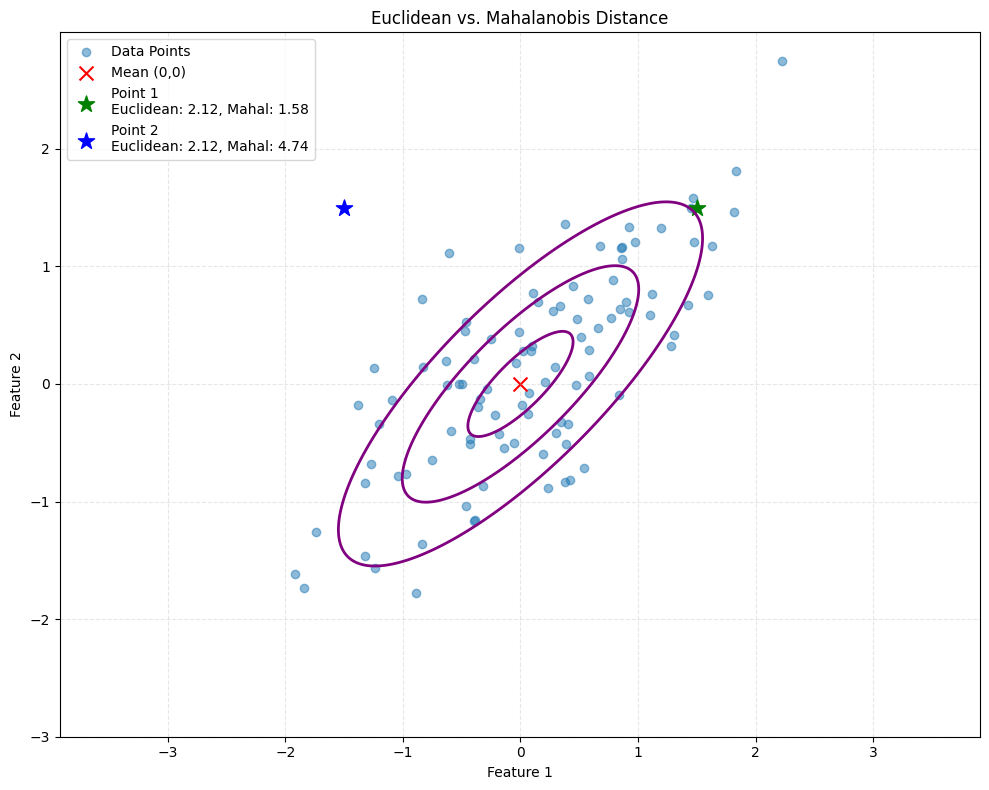

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from scipy.stats import multivariate_normal

# Set random seed for reproducibility
np.random.seed(42)

# Generate 2D Gaussian random points with high correlation
mean = [0, 0]
cov = [[1, 0.8], [0.8, 1]]  # Covariance matrix
points = np.random.multivariate_normal(mean, cov, 100)

# Select two points with the same Euclidean distance to the center but different locations
# Point 1 is along the direction of high variance
# Point 2 is along the direction of low variance
point1 = np.array([1.5, 1.5])
point2 = np.array([-1.5, 1.5])

# Compute Euclidean distances
center = np.array(mean)
euclidean_dist1 = np.linalg.norm(point1 - center)
euclidean_dist2 = np.linalg.norm(point2 - center)

# Compute Mahalanobis distances
inv_cov = np.linalg.inv(cov)
mahalanobis_dist1 = mahalanobis(point1, center, inv_cov)
mahalanobis_dist2 = mahalanobis(point2, center, inv_cov)

# Plot the data and points
plt.figure(figsize=(10, 8))
plt.scatter(points[:, 0], points[:, 1], alpha=0.5, label='Data Points')
plt.scatter(center[0], center[1], color='red', marker='x', s=100, label='Mean (0,0)')

# Highlight the two comparison points
plt.scatter(point1[0], point1[1], color='green', marker='*', s=150, 
            label=f'Point 1\nEuclidean: {euclidean_dist1:.2f}, Mahal: {mahalanobis_dist1:.2f}')
plt.scatter(point2[0], point2[1], color='blue', marker='*', s=150, 
            label=f'Point 2\nEuclidean: {euclidean_dist2:.2f}, Mahal: {mahalanobis_dist2:.2f}')

# Plot the probability contours
x, y = np.mgrid[-3:3:.01, -3:3:.01]
pos = np.dstack((x, y))
rv = multivariate_normal(mean, cov)
plt.contour(x, y, rv.pdf(pos), levels=3, colors='purple', linewidths=2)

plt.legend()
plt.title('Euclidean vs. Mahalanobis Distance')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

*Observation:* Point 1 and Point 2 have the same Euclidean distance from the center, yet they lie in different "probability regions." Point 2 is in a direction of lower variance (orthogonal to the main correlation), making it statistically less likely (further in Mahalanobis distance) than Point 1.

---

## The effect of feature scaling

### Case Study: Iranian Missile Similarity

In this example, we will use a dataset of **Iranian Ballistic Missiles** to solve a similarity problem. We want to determine which missile is more similar to the **Khaybar Shikan** (Missile A) based on **Range** and **Speed**.

#### 1. The Dataset
We have the following data for three missiles:

<!-- | Missile | Range (km) | Speed (Mach) |
| :--- | :--- | :--- |
| **A. Khaybar Shikan** (Target) | 1,450 | 5 |
| **B. Sejjil** | 2,000 | 10 |
| **C. Fatāh** | 1,400 | 14 | -->

<html>
  <table>
    <tr>
      <th>Missile</th>
      <th>Range (km)</th>
      <th>Speed (Mach)</th>
    </tr>
    <tr>
      <td>A. Khaybar Shikan</td>
      <td>1,450</td>
      <td>5</td>
      <td><img src="_images/Khaybar.jpg" width=300></td>
    </tr>
    <tr>
      <td>B. Sejjil</td>
      <td>2,000</td>
      <td>10</td>
      <td><img src="_images/Sejjil.jpg" width=300></td>
    </tr>
    <tr>
      <td>C. Fatāh</td>
      <td>1,400</td>
      <td>14</td>
      <td><img src="_images/Fattah.jpg" width=300></td>
    </tr>
  </table>
</html>


#### 2. The Naive Approach (Raw Distance)
Using standard Euclidean distance, we calculate the distance between the Target (Khaybar) and the other missiles.

*   **Khaybar vs. Sejjil (B):**
    *   $\Delta \text{Range} = |2000 - 1450| = 550 \text{ km}$
    *   $\Delta \text{Speed} = |10 - 5| = 5 \text{ Mach}$
    *   $D_{raw} = \sqrt{550^2 + 5^2} = \sqrt{302,500 + 25} \approx \mathbf{550.02}$

*   **Khaybar vs. Fatāh (C):**
    *   $\Delta \text{Range} = |1400 - 1450| = 50 \text{ km}$
    *   $\Delta \text{Speed} = |14 - 5| = 9 \text{ Mach}$
    *   $D_{raw} = \sqrt{50^2 + 9^2} = \sqrt{2,500 + 81} \approx \mathbf{50.80}$

**❌ Problem:** Fatāh looks much closer (50.8) than Sejjil (550.0).
**Reality Check:** 50 km is negligible in missile range, but 9 Mach is a massive difference in speed class (Hypersonic vs. Medium). The raw calculation is dominated by the **Range** feature.

#### 3. The Corrected Approach (Standard Scaling)
To fix this, we normalize the data using Z-scores ($Z = \frac{x - \mu}{\sigma}$). This puts both features on the same scale.

**Dataset Statistics (from Code Output):**
*   **Range:** Mean = 1,616.67 km | **Std Dev (Sample)** $\approx$ 332.92 km
*   **Speed:** Mean = 9.67 Mach | **Std Dev (Sample)** $\approx$ 4.51 Mach

*Note: The `StandardScaler` algorithm typically uses Population Std Dev (approx 272 km / 3.7 Mach) for internal transformation to ensure consistency, which results in the final distances below.*

**A. Khaybar vs. Sejjil (B):**
*   $D_{scaled} = \sqrt{1.90^2 + 1.40^2} \approx \mathbf{2.44}$

**B. Khaybar vs. Fatāh (C):**
*   $D_{scaled} = \sqrt{0.20^2 + 2.40^2} \approx \mathbf{2.45}$


#### 4. The Result
| Comparison | Raw Distance | **Scaled Distance** |
| :--- | :--- | :--- |
| **Khaybar vs. Sejjil** | 550.02 | **2.44** ✅ |
| **Khaybar vs. Fatāh** | 50.80 | **2.45** |

**✅ Result:** **Sejjil** (2.44) is now correctly identified as the closest match to Khaybar, not Fatāh.

#### 5. Why the Change?
1.  **Raw Data:** The Range feature (km) was numerically huge (1400-2000) compared to Speed (5-14). The algorithm ignored Speed because a change of 50 km is a tiny percentage of the total range, but a change of 9 Mach is a **180% change** in Speed.
2.  **Scaled Data:** By dividing by the Standard Deviation, we turned Speed into the dominant factor.
3.  **Conclusion:** The Scaled Distance penalizes the massive speed difference in Fatāh, correctly identifying Sejjil as the more similar missile platform.

---

### Code Logic Summary
The Python script used **`StandardScaler`** to handle this automatically. It:
1.  Calculated the Mean and Standard Deviation for each column.
2.  Transformed the values into Z-scores.
3.  Calculated Euclidean distance on the **transformed** (standardized) data.

This ensures features with different units (km vs Mach) contribute equally to the similarity score.

In [63]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ============================================
# 1. REALISTIC IRANIAN MISSILE DATASET
# ============================================
data = {
    'Name': ['Khaybar Shikan', 'Sejjil', 'Fatāh'],
    'Range_km': [1450, 2000, 1400],
    'Speed_Mach': [5, 10, 14]
}

df = pd.DataFrame(data)
df.set_index('Name', inplace=True)

# Target: Compare Khaybar Shikan to Sejjil and Fatāh
target_name = 'Khaybar Shikan'
target = df.loc[target_name].values
other_names = ['Sejjil', 'Fatāh']
others = df.loc[other_names].values

# ============================================
# 2. RAW EUCLIDEAN DISTANCE (Unscaled)
# ============================================
raw_dist = np.linalg.norm(others - target, axis=1)

print("=== RAW EUCLIDEAN DISTANCE (Unscaled) ===")
for name, dist in zip(other_names, raw_dist):
    print(f"Distance to {name}: {dist:.2f}")

# ============================================
# 3. SCALED EUCLIDEAN DISTANCE (Standardized)
# ============================================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['Range_km', 'Speed_Mach']])
df_scaled = pd.DataFrame(scaled_data, index=df.index, columns=df.columns)

target_scaled = df_scaled.loc[target_name].values
others_scaled = df_scaled.loc[other_names].values

scaled_dist = np.linalg.norm(others_scaled - target_scaled, axis=1)

print("\n=== SCALED EUCLIDEAN DISTANCE (Normalized) ===")
for name, dist in zip(other_names, scaled_dist):
    print(f"Distance to {name}: {dist:.2f}")

# ============================================
# 4. SHOW THE FLIP
# ============================================
raw_winner = other_names[np.argmin(raw_dist)]
scaled_winner = other_names[np.argmin(scaled_dist)]

print("\n--- ANALYSIS ---")
print(f"Raw Distance Winner (Misleading): {raw_winner}")
print(f"Scaled Distance Winner (Correct): {scaled_winner}")

# ============================================
# 5. SHOW STATISTICS
# ============================================
print("\n--- DATASET STATISTICS ---")
print(f"Range Std Dev: {df['Range_km'].std():.2f} km")
print(f"Speed Std Dev: {df['Speed_Mach'].std():.2f} Mach")


=== RAW EUCLIDEAN DISTANCE (Unscaled) ===
Distance to Sejjil: 550.02
Distance to Fatāh: 50.80

=== SCALED EUCLIDEAN DISTANCE (Normalized) ===
Distance to Sejjil: 2.44
Distance to Fatāh: 2.45

--- ANALYSIS ---
Raw Distance Winner (Misleading): Fatāh
Scaled Distance Winner (Correct): Sejjil

--- DATASET STATISTICS ---
Range Std Dev: 332.92 km
Speed Std Dev: 4.51 Mach


### Key Takeaway 
When building ML models, **Unit Mismatch** is a silent killer.

Always scale your features (Standardization/Normalization) before calculating distances, training Neural Networks, or using K-Means Clustering.

## 2. Introduction to Covariance Matrix

The **covariance matrix** is a square matrix that summarizes the variances and covariances of a set of random variables. For a dataset with $d$ features, the covariance matrix $\boldsymbol{\Sigma}$ is a $d \times d$ matrix defined as:

$$
\boldsymbol{\Sigma} = \begin{bmatrix}
\sigma_{11} & \sigma_{12} & \cdots & \sigma_{1d} \\
\sigma_{21} & \sigma_{22} & \cdots & \sigma_{2d} \\
\vdots & \vdots & \ddots & \vdots \\
\sigma_{d1} & \sigma_{d2} & \cdots & \sigma_{dd}
\end{bmatrix}
$$

Where:
*   $\sigma_{ii} = \operatorname{Var}(x_i)$: The variance of the $i$-th feature (diagonal elements).
*   $\sigma_{ij} = \operatorname{Cov}(x_i, x_j)$: The covariance between the $i$-th and $j$-th features (off-diagonal elements).

**Properties:**
1.  **Symmetric:** $\sigma_{ij} = \sigma_{ji}$, so $\boldsymbol{\Sigma} = \boldsymbol{\Sigma}^{\top}$.
2.  **Positive Semi-Definite:** All eigenvalues are non-negative ($\lambda_i \geq 0$).

---

## 3. Geometric Interpretation of Covariance Matrix

The covariance matrix defines the **shape** and **orientation** of the data distribution in the feature space.

1.  **Eigenvectors (Directions):** The eigenvectors of $\boldsymbol{\Sigma}$ represent the principal axes of the data distribution. They indicate the directions of maximum variance.
2.  **Eigenvalues (Magnitudes):** The corresponding eigenvalues represent the magnitude of variance along these eigenvector directions.
3.  **Ellipsoid:** In 2D, the covariance matrix defines an ellipse. In $d$-dimensions, it defines a hyper-ellipsoid. The axes of this ellipsoid are aligned with the eigenvectors, and the lengths of the axes are proportional to the square roots of the eigenvalues.

---

**Whitening Transformation**

Whitening is a process that transforms data so that its covariance matrix becomes the identity matrix. This transformation removes correlations between features and scales the features to have unit variance. Whitening is particularly useful in machine learning and signal processing because it simplifies the structure of the data, making it easier to apply algorithms that assume uncorrelated features.

![Figure 2.8 of Duda](img/Duda-Figure-2.8.png)

Figure 2.8 {cite}`Duda2000`: The action of a linear transformation on the feature space will convert an arbitrary normal distribution into another normal distribution. 

In the following we will see that a linear transformation $W^{\!\top}$ applied to a zero-mean vector $\mathbf{x}-\boldsymbol{\mu}$ produces a new vector whose covariance is obtained by "sandwiching" the old covariance between $W^{\!\top}$ and $W$. This property is fundamental to **whitening**, where we choose $W$ specifically so that the new covariance becomes the Identity matrix $\mathbf{I}$.


*Example: Whitening in Python*

The following Python code demonstrates how to whiten a dataset:



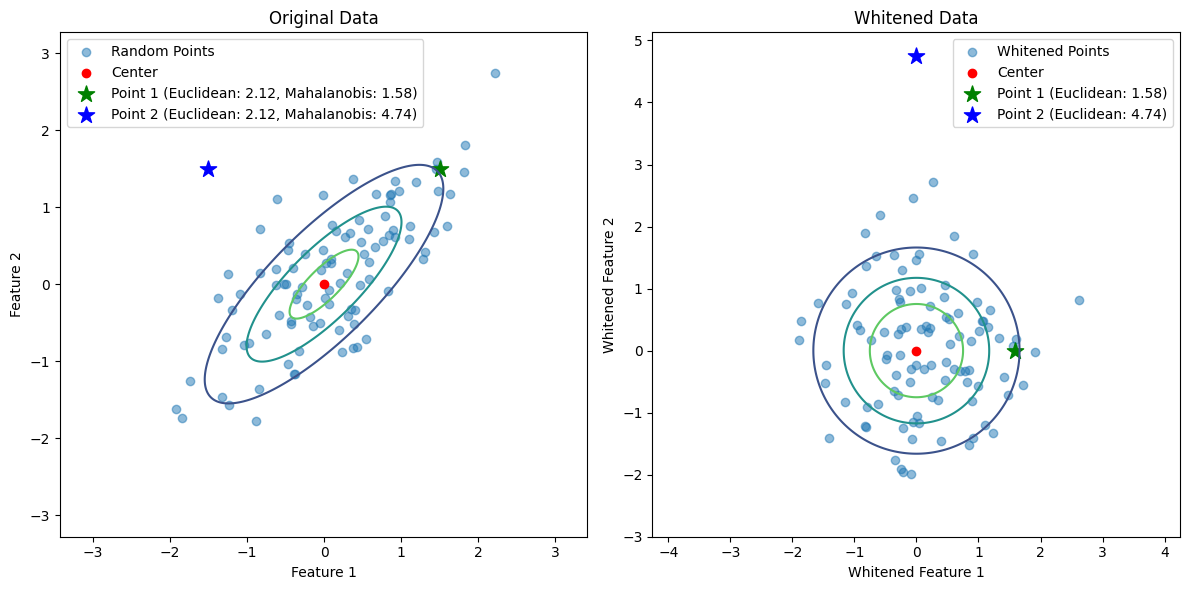

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from scipy.stats import multivariate_normal

# Generate 2D Gaussian random points
np.random.seed(42)
mean = [0, 0]
cov = [[1, 0.8], [0.8, 1]]  # Covariance matrix
points = np.random.multivariate_normal(mean, cov, 100)

# The center
center = mean

# Select two points with equal Euclidean distance to the center
point1 = np.array([1.5, 1.5])
point2 = np.array([-1.5, 1.5])

# Compute Euclidean distances
euclidean_dist1 = np.linalg.norm(point1 - center)
euclidean_dist2 = np.linalg.norm(point2 - center)

# Compute Mahalanobis distances
inv_cov = np.linalg.inv(cov)
mahalanobis_dist1 = mahalanobis(point1, center, inv_cov)
mahalanobis_dist2 = mahalanobis(point2, center, inv_cov)

# Whitening the data based on Duda's book
# Step 1: Compute the eigenvalues and eigenvectors of the covariance matrix
eigenvals, eigenvecs = np.linalg.eigh(cov)
idx = np.argsort(eigenvals)[::-1]
eigenvals = eigenvals[idx]
eigenvecs = eigenvecs[:, idx]

# Step 2: Construct the whitening matrix
D = np.diag(1.0 / np.sqrt(eigenvals))  # Diagonal matrix of inverse square roots of eigenvalues
W = np.dot(eigenvecs, D)  # Whitening matrix

# Step 3: Whiten the data
whitened_points = np.dot(points - center, W)  # Subtract mean and apply whitening transformation
whitened_point1 = np.dot(point1 - center, W)
whitened_point2 = np.dot(point2 - center, W)

# Compute Euclidean distances in the whitened space
whitened_euclidean_dist1 = np.linalg.norm(whitened_point1)
whitened_euclidean_dist2 = np.linalg.norm(whitened_point2)

# Plot the original and whitened data
plt.figure(figsize=(12, 6))

# Plot original data
plt.subplot(1, 2, 1)
plt.scatter(points[:, 0], points[:, 1], alpha=0.5, label='Random Points')
plt.scatter(center[0], center[1], color='red', label='Center')
plt.scatter(point1[0], point1[1], color='green', marker='*', s=150, label=f'Point 1 (Euclidean: {euclidean_dist1:.2f}, Mahalanobis: {mahalanobis_dist1:.2f})')
plt.scatter(point2[0], point2[1], color='blue', marker='*', s=150, label=f'Point 2 (Euclidean: {euclidean_dist2:.2f}, Mahalanobis: {mahalanobis_dist2:.2f})')

# Create a grid of points for the original data
x, y = np.mgrid[-3:3:.01, -3:3:.01]
pos = np.dstack((x, y))

# Compute the Gaussian distribution on the grid
rv = multivariate_normal(mean, cov)
plt.contour(x, y, rv.pdf(pos), levels=3, cmap='viridis')

plt.legend()
plt.title('Original Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.axis('equal')

# Plot whitened data
plt.subplot(1, 2, 2)
plt.scatter(whitened_points[:, 0], whitened_points[:, 1], alpha=0.5, label='Whitened Points')
plt.scatter(0, 0, color='red', label='Center')
plt.scatter(whitened_point1[0], whitened_point1[1], color='green', marker='*', s=150, label=f'Point 1 (Euclidean: {whitened_euclidean_dist1:.2f})')
plt.scatter(whitened_point2[0], whitened_point2[1], color='blue', marker='*', s=150, label=f'Point 2 (Euclidean: {whitened_euclidean_dist2:.2f})')

# Create a grid of points for the whitened data
x_whitened, y_whitened = np.mgrid[-3:3:.01, -3:3:.01]
pos_whitened = np.dstack((x_whitened, y_whitened))

# Compute the Gaussian distribution on the grid for whitened data
rv_whitened = multivariate_normal([0, 0], np.eye(2))  # Covariance matrix is identity after whitening
plt.contour(x_whitened, y_whitened, rv_whitened.pdf(pos_whitened), levels=3, cmap='viridis')

plt.legend()
plt.title('Whitened Data')
plt.xlabel('Whitened Feature 1')
plt.ylabel('Whitened Feature 2')
plt.axis('equal')

plt.tight_layout()
plt.show()


## 4. Linear Transformations and Covariance

To fully understand Mahalanobis distance and whitening, we must understand how covariance changes under linear transformations. The following theorem provides the mathematical foundation for transforming data to a "whitened" space.

### **Theorem 1 (Covariance Transformation Property)**

Let $\mathbf{x} \in \mathbb{R}^d$ be a random vector with mean $\boldsymbol{\mu} = \mathbb{E}[\mathbf{x}]$ and covariance matrix $\boldsymbol{\Sigma} = \operatorname{Cov}(\mathbf{x})$. Let $W \in \mathbb{R}^{d \times d}$ be a constant transformation matrix. If the transformed random vector $\mathbf{y}$  defines as $\mathbf{y} = W^{\!\top}\bigl(\mathbf{x} - \boldsymbol{\mu}\bigr)$; then, the covariance matrix of the transformed vector $\mathbf{y}$ be as follows:

$$
\boxed{\operatorname{Cov}(\mathbf{y}) = W^{\!\top}\boldsymbol{\Sigma}W}
$$

**Proof:**
We proceed by applying the definition of covariance and the linearity of expectation.

1.  **Mean of $\mathbf{y}$:**
    First, observe that the mean of the centered vector is zero:

    $$
    \begin{aligned}
    \mathbb{E}[\mathbf{y}]
    &= \mathbb{E}\bigl[W^{\!\top}(\mathbf{x} - \boldsymbol{\mu})\bigr] \\
    &= W^{\!\top}\bigl(\mathbb{E}[\mathbf{x}] - \boldsymbol{\mu}\bigr) \\
    &= W^{\!\top}(\boldsymbol{\mu} - \boldsymbol{\mu}) \\
    &= \mathbf{0}.
    \end{aligned}
    $$



2.  **Covariance of $\mathbf{y}$:**

    $$\text{Cov}(\mathbf{y}) = \mathbb{E}[(\mathbf{y} - \mathbb{E}[\mathbf{y}])(\mathbf{y} - \mathbb{E}[\mathbf{y}])^T]$$

    Since $\mathbb{E}[\mathbf{y}] = \mathbf{0}$, the covariance definition simplifies to $\operatorname{Cov}(\mathbf{y}) = \mathbb{E}[\mathbf{y}\mathbf{y}^{\!\top}]$.

    $$
    \begin{aligned}
    \operatorname{Cov}(\mathbf{y})
    &= \mathbb{E}\bigl[\mathbf{y}\,\mathbf{y}^{\!\top}\bigr] \\
    &= \mathbb{E}\Big[W^{\!\top}(\mathbf{x}-\boldsymbol{\mu})\,(\mathbf{x}-\boldsymbol{\mu})^{\!\top}W\Big].
    \end{aligned}
    $$

    By the linearity of the expectation operator, constant matrices $W^{\!\top}$ and $W$ can be pulled out of the expectation:

    $$
    \begin{aligned}
    \operatorname{Cov}(\mathbf{y})
    &= W^{\!\top}\;\mathbb{E}\Big[(\mathbf{x}-\boldsymbol{\mu})(\mathbf{x}-\boldsymbol{\mu})^{\!\top}\Big]\;W.
    \end{aligned}
    $$

    Recognizing that the term inside the expectation is exactly the definition of $\operatorname{Cov}(\mathbf{x}) = \boldsymbol{\Sigma}$:

    $$
    \operatorname{Cov}(\mathbf{y}) = W^{\!\top}\boldsymbol{\Sigma}W. \quad \square
    $$

**Remark (Whitening Application):**
This property is fundamental to **whitening**. By choosing $W$ such that $W^{\!\top}\boldsymbol{\Sigma}W = \mathbf{I}$, we transform the data into a space where features are uncorrelated and have unit variance. As shown in Section 5, this $W$ is constructed using the eigendecomposition of $\boldsymbol{\Sigma}$.


## 5. Whitening Transformation

**Whitening** is a preprocessing step that transforms data so that its covariance matrix becomes the Identity matrix ($\mathbf{I}$). This implies the transformed features are **uncorrelated** and have **unit variance**.

### Mathematical Formulation

We seek a transformation matrix $W$ such that if $\mathbf{y} = W^{\top}(\mathbf{x} - \boldsymbol{\mu})$, then $\operatorname{Cov}(\mathbf{y}) = \mathbf{I}$.

From the proof in Section 4:

$$ \operatorname{Cov}(\mathbf{y}) = W^{\!\top}\boldsymbol{\Sigma}W = \mathbf{I} $$

We can solve for $W$ using the **Eigen Decomposition** of $\boldsymbol{\Sigma}$. Let $\boldsymbol{\Sigma} = \Phi \Lambda \Phi^{\top}$, where:
*   $\Phi$ is the orthogonal matrix of eigenvectors.
*   $\Lambda$ is the diagonal matrix of eigenvalues.

We choose $W = \Phi \Lambda^{-1/2}$. Let's verify:

$$
\begin{aligned}
\operatorname{Cov}(\mathbf{y}) &= (\Phi \Lambda^{-1/2})^{\top} \boldsymbol{\Sigma} (\Phi \Lambda^{-1/2}) \\
&= \Lambda^{-1/2} \Phi^{\top} (\Phi \Lambda \Phi^{\top}) \Phi \Lambda^{-1/2} \\
&= \Lambda^{-1/2} (\Phi^{\top} \Phi) \Lambda (\Phi^{\top} \Phi) \Lambda^{-1/2} \\
&= \Lambda^{-1/2} (\mathbf{I}) \Lambda (\mathbf{I}) \Lambda^{-1/2} \\
&= \mathbf{I}.
\end{aligned}
$$

### Geometric Interpretation

1.  **Rotation ($\Phi^{\top}$):** Aligns the data with the principal axes (removes correlations).
2.  **Scaling ($\Lambda^{-1/2}$):** Stretches or compresses the data along these axes so that all axes have length 1 (unit variance).

**Result:** The data cloud becomes a perfect sphere (isotropic). In this whitened space, the **Euclidean distance is equivalent to the Mahalanobis distance** in the original space.

---

## 6. Mahalanobis Distance



The **Mahalanobis distance** is a measure of the distance between a point $\mathbf{x}$ and a distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\mathbf{\Sigma}$. It is defined as:

$$D_M(\mathbf{x}, \boldsymbol{\mu}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})}$$

This distance is central to many multivariate statistical methods, including Bayesian decision theory for classification, because it accounts for the underlying structure (variances and correlations) of the data.

### The Key Insight

The covariance transformation formula from Section 4 is **the fundamental mathematical foundation** for both whitening transformation and Mahalanobis distance.

**Recall the Mahalanobis distance:**

$$ D_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})} $$

**Now consider the whitened space:**
If we define $\mathbf{y} = W^{\!\top}(\mathbf{x}-\boldsymbol{\mu})$ where $W$ makes $\operatorname{Cov}(\mathbf{y}) = \mathbf{I}$, then:

$$ \|\mathbf{y}\|_2 = \sqrt{\mathbf{y}^T \mathbf{y}} = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T W W^{\!\top} (\mathbf{x} - \boldsymbol{\mu})} $$

For this to equal the Mahalanobis distance, we need to show that $ W W^{\!\top} = \boldsymbol{\Sigma}^{-1} $.

**Proof:**

We are given: $ \boldsymbol{\Sigma} = \Phi \Lambda \Phi^{\top} $ and  $ W = \Phi \Lambda^{-1/2} $

We aim to show that  $W W^{\!\top} = \boldsymbol{\Sigma}^{-1}$


**Step 1: Compute $ W W^{\!\top} $**

Substitute $ W = \Phi \Lambda^{-1/2} $:

$$
W W^{\!\top}
= (\Phi \Lambda^{-1/2}) (\Phi \Lambda^{-1/2})^{\!\top}
$$

Now, transpose the second factor:

$$
(\Phi \Lambda^{-1/2})^{\!\top}
= (\Lambda^{-1/2})^{\!\top} \Phi^{\!\top}
$$

Since $ \Lambda $ is a diagonal matrix with positive eigenvalues (implying invertibility), $ \Lambda^{-1/2} $ is also diagonal and symmetric, so:

$$
(\Lambda^{-1/2})^{\!\top} = \Lambda^{-1/2}
$$

Thus,

$$
W W^{\!\top}
= \Phi \Lambda^{-1/2} (\Lambda^{-1/2}) \Phi^{\!\top}
= \Phi (\Lambda^{-1/2} \cdot \Lambda^{-1/2}) \Phi^{\!\top}
= \Phi \Lambda^{-1} \Phi^{\!\top}
$$


**Step 2: Compute $ \boldsymbol{\Sigma}^{-1} $ using the inverse of a diagonalized matrix**

We are given:

$$
\boldsymbol{\Sigma} = \Phi \Lambda \Phi^{\!\top}
$$

Since $ \Phi $ is an orthogonal matrix (i.e., $ \Phi^{\!\top} \Phi = I $), we know that:

$$
(\Phi \Lambda \Phi^{\!\top})^{-1}
= (\Phi^{\!\top})^{-1} \Lambda^{-1} \Phi^{-1}
$$

Because $ \Phi $ is orthogonal:
- $ \Phi^{-1} = \Phi^{\!\top} $
- So $ (\Phi^{\!\top})^{-1} = \Phi $

Therefore,

$$
(\Phi \Lambda \Phi^{\!\top})^{-1}
= \Phi \Lambda^{-1} \Phi^{\!\top}
$$


We have shown that:

$$
\boxed{W W^{\!\top} = \boldsymbol{\Sigma}^{-1}}
$$

**Key insight**: The orthogonality of $ \Phi $ allows us to simplify the inverse of $ \Phi \Lambda \Phi^{\!\top} $ elegantly, which is essential for establishing the result.



### Key Relationship

| Concept | Mathematical Expression | Purpose |
|---------|-----|---------|
| **Covariance Transformation** | $\operatorname{Cov}(\mathbf{y}) = W^{\!\top}\boldsymbol{\Sigma}W$ | Describes how covariance changes under linear transformation |
| **Whitening Matrix** | $W = \Phi \Lambda^{-1/2}$ | Transforms data to unit covariance |
| **Mahalanobis Distance** | $D_M = \sqrt{(\mathbf{x}-\boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})}$ | Distance accounting for covariance structure |
| **Euclidean Distance (Whitened)** | $\|\mathbf{y}\|_2 = \sqrt{\mathbf{y}^T\mathbf{y}}$ | Distance after covariance normalization |
| **Key Equivalence** | $D_M(\mathbf{x}) = \|\mathbf{y}\|_2$ | Mahalanobis = Euclidean in whitened space |

---


## 7. Python Implementation: Step-by-Step Demonstration

In [88]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

np.random.seed(42)

# ============================================================================
# 1. GENERATE CORRELATED DATA
# ============================================================================
print("=" * 70)
print("STEP 1: Generate Correlated Data (Original Space)")
print("=" * 70)

mean = np.array([1, 2])
cov_original = np.array([[4, 3], [3, 4]])  # Correlated data
n_samples = 500
data_original = np.random.multivariate_normal(mean, cov_original, n_samples)

print(f"Original Covariance:\n{cov_original}")

# ============================================================================
# 2. EIGEN DECOMPOSITION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 2: Eigen Decomposition (Rotation + Scaling Factors)")
print("=" * 70)

eigenvalues, eigenvectors = np.linalg.eigh(cov_original)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
print(f"\nEigenvalues (λ): {eigenvalues}")
print(f"\nEigenvectors (Φ):")
print(eigenvectors)


STEP 1: Generate Correlated Data (Original Space)
Original Covariance:
[[4 3]
 [3 4]]

STEP 2: Eigen Decomposition (Rotation + Scaling Factors)

Eigenvalues (λ): [7. 1.]

Eigenvectors (Φ):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [89]:

# ============================================================================
# 3. ROTATION ONLY 
# ============================================================================
print("\n" + "=" * 70)
print("STEP 3: Rotation Only")
print("=" * 70)

data_rotated = (data_original - mean) @ eigenvectors
cov_rotated = np.cov(data_rotated.T)

print(f"\nCovariance after Rotation (should be diagonal):")
print(cov_rotated)
print(f"Off-diagonal before rotation: {cov_original[0, 1]:.4f}")
print(f"Off-diagonal after rotation: {cov_rotated[0, 1]:.4f}")

# ============================================================================
# 4. SCALING ONLY (Normalize to Unit Variance)
# ============================================================================
print("\n" + "=" * 70)
print("STEP 4: Scaling Only (Λ^(-1/2) normalizes variance)")
print("=" * 70)

scale_factors = 1.0 / np.sqrt(eigenvalues)
data_scaled = data_rotated @ np.diag(scale_factors)
cov_scaled = np.cov(data_scaled.T)

print(f"\nCovariance after Scaling (should be Identity):")
print(cov_scaled)



STEP 3: Rotation Only

Covariance after Rotation (should be diagonal):
[[6.54609064 0.06692453]
 [0.06692453 0.98399756]]
Off-diagonal before rotation: 3.0000
Off-diagonal after rotation: 0.0669

STEP 4: Scaling Only (Λ^(-1/2) normalizes variance)

Covariance after Scaling (should be Identity):
[[0.93515581 0.02529509]
 [0.02529509 0.98399756]]


In [90]:

# ============================================================================
# 5. WHITENING (Rotation + Scaling)
# ============================================================================
print("\n" + "=" * 70)
print("STEP 5:  Whitening (W = ΦΛ^(-1/2))")
print("=" * 70)

W = eigenvectors @ np.diag(scale_factors)
data_whitened = W.T @ (data_original - mean).T
data_whitened = data_whitened.T

print(f"\nWhitening Matrix (W = ΦΛ^(-1/2)):")
print(W)
print(f"\nCovariance after Whitening (W^T Σ W):")
print(np.cov(data_whitened.T))


STEP 5:  Whitening (W = ΦΛ^(-1/2))

Whitening Matrix (W = ΦΛ^(-1/2)):
[[ 0.26726124 -0.70710678]
 [ 0.26726124  0.70710678]]

Covariance after Whitening (W^T Σ W):
[[0.93515581 0.02529509]
 [0.02529509 0.98399756]]



STEP 6: Visualization of Transformation


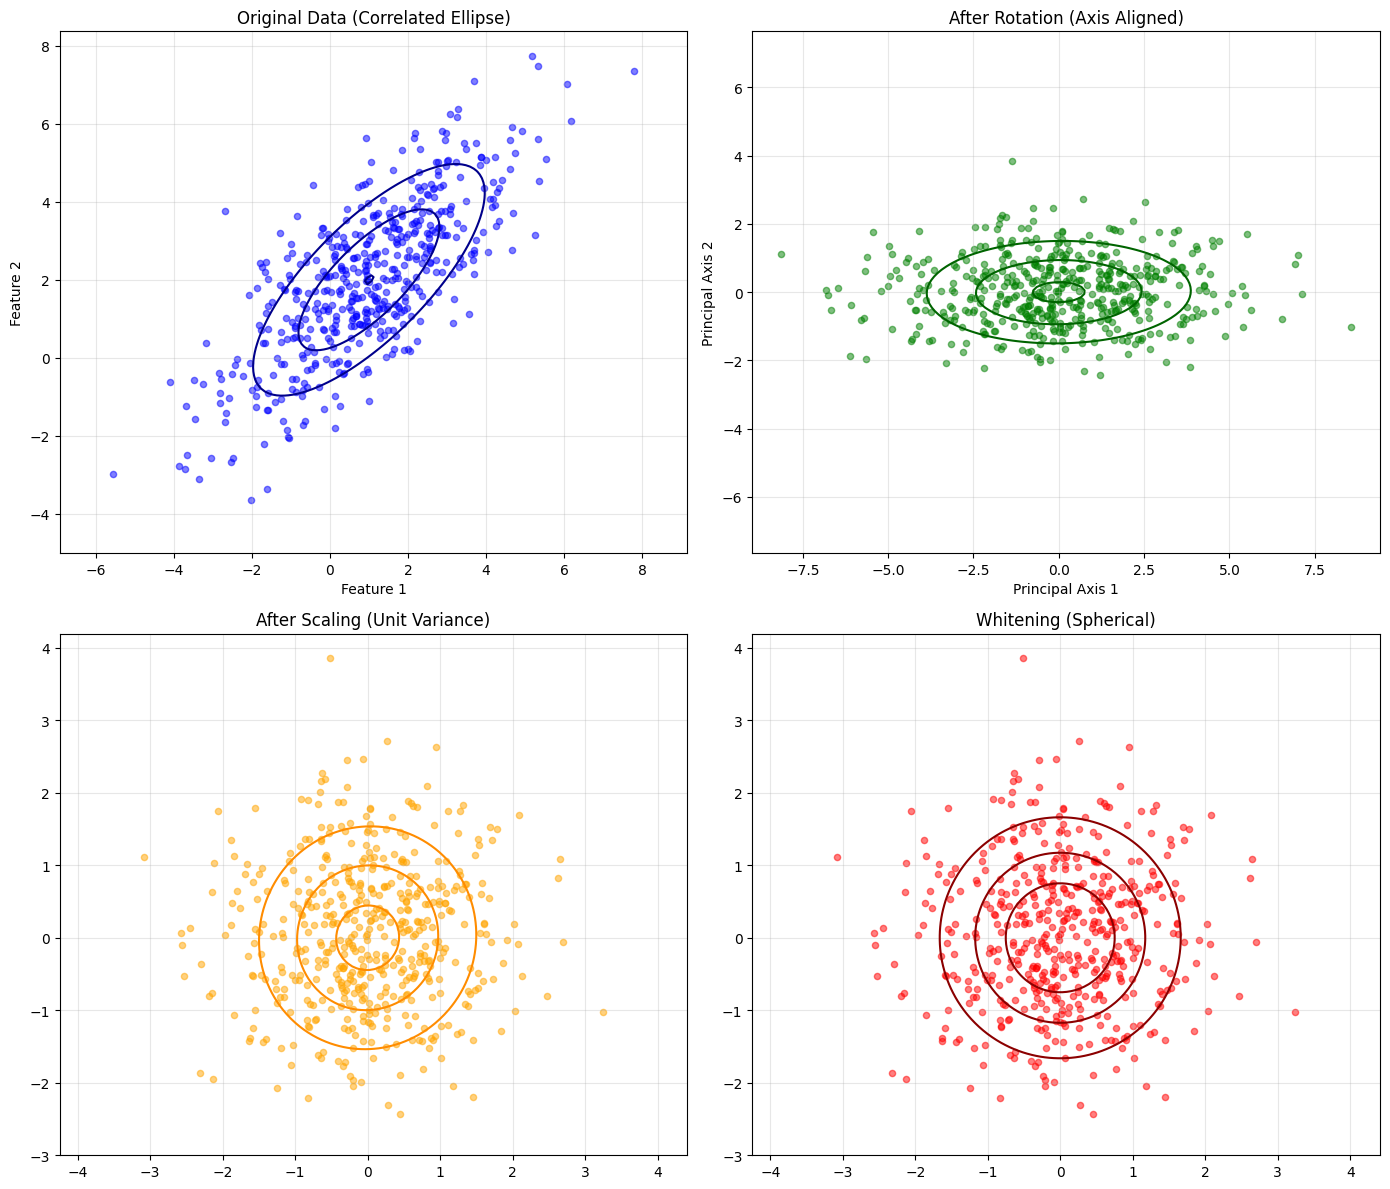

In [91]:

# ============================================================================
# 6. VISUALIZATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 6: Visualization of Transformation")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Original Data
axes[0, 0].scatter(data_original[:, 0], data_original[:, 1], alpha=0.5, s=20, color='blue', label='Original')
pos = np.dstack(np.mgrid[-5:5:100j, -5:5:100j])
axes[0, 0].contour(pos[:,:,0], pos[:,:,1], multivariate_normal(mean, cov_original).pdf(pos), levels=3, colors='darkblue')
axes[0, 0].set_title('Original Data (Correlated Ellipse)')
axes[0, 0].set_xlabel('Feature 1'); axes[0, 0].set_ylabel('Feature 2')
axes[0, 0].grid(True, alpha=0.3); axes[0, 0].axis('equal')

# After Rotation
axes[0, 1].scatter(data_rotated[:, 0], data_rotated[:, 1], alpha=0.5, s=20, color='green', label='Rotated')
pos = np.dstack(np.mgrid[-5:5:100j, -5:5:100j])
axes[0, 1].contour(pos[:,:,0], pos[:,:,1], multivariate_normal(np.zeros(2), cov_rotated).pdf(pos), levels=3, colors='darkgreen')
axes[0, 1].set_title('After Rotation (Axis Aligned)')
axes[0, 1].set_xlabel('Principal Axis 1'); axes[0, 1].set_ylabel('Principal Axis 2')
axes[0, 1].grid(True, alpha=0.3); axes[0, 1].axis('equal')

# After Scaling
axes[1, 0].scatter(data_scaled[:, 0], data_scaled[:, 1], alpha=0.5, s=20, color='orange', label='Scaled')
pos = np.dstack(np.mgrid[-3:3:100j, -3:3:100j])
axes[1, 0].contour(pos[:,:,0], pos[:,:,1], multivariate_normal(np.zeros(2), cov_scaled).pdf(pos), levels=3, colors='darkorange')
axes[1, 0].set_title('After Scaling (Unit Variance)')
axes[1, 0].grid(True, alpha=0.3); axes[1, 0].axis('equal')

# Combined Whitening
axes[1, 1].scatter(data_whitened[:, 0], data_whitened[:, 1], alpha=0.5, s=20, color='red', label='Whitened')
pos = np.dstack(np.mgrid[-3:3:100j, -3:3:100j])
axes[1, 1].contour(pos[:,:,0], pos[:,:,1], multivariate_normal(np.zeros(2), np.eye(2)).pdf(pos), levels=3, colors='darkred')
axes[1, 1].set_title('Whitening (Spherical)')
axes[1, 1].grid(True, alpha=0.3); axes[1, 1].axis('equal')

plt.tight_layout()
plt.show()


In [92]:

# ============================================================================
# 7. MAHALANOBIS DISTANCE VERIFICATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 7: Mahalanobis Distance = Euclidean in Whitened Space")
print("=" * 70)

test_point = np.array([4, 4])
inv_cov = np.linalg.inv(cov_original)
mahalanobis_dist = np.sqrt((test_point - mean) @ inv_cov @ (test_point - mean))
test_point_whitened = W.T @ (test_point - mean)
euclidean_dist_whitened = np.linalg.norm(test_point_whitened)

print(f"\nTest Point: {test_point}")
print(f"Mahalanobis Distance (Original Space): {mahalanobis_dist:.4f}")
print(f"Euclidean Distance (Whitened Space): {euclidean_dist_whitened:.4f}")
print(f"\n✓ Mahalanobis Distance = Euclidean Distance in Whitened Space!")


STEP 7: Mahalanobis Distance = Euclidean in Whitened Space

Test Point: [4 4]
Mahalanobis Distance (Original Space): 1.5119
Euclidean Distance (Whitened Space): 1.5119

✓ Mahalanobis Distance = Euclidean Distance in Whitened Space!



## 8. Covariance Matrix in Bayesian Decision Theory


$$
p(\mathbf{x}|\omega_i) = \frac{1}{(2\pi)^{d/2}|\boldsymbol{\Sigma}_i|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_i)^T \boldsymbol{\Sigma}_i^{-1} (\mathbf{x} - \boldsymbol{\mu}_i)\right)
$$

*   $\boldsymbol{\mu}_i$: Mean vector for class $\omega_i$.
*   $\boldsymbol{\Sigma}_i$: Covariance matrix for class $\omega_i$.

The term in the exponent is exactly half the **squared Mahalanobis distance**. The covariance matrix determines the "tightness" and orientation of the decision boundaries.

---

## 9. Mahalanobis Distance and Its Role

The **Mahalanobis distance** measures the distance between a point $\mathbf{x}$ and a distribution (characterized by mean $\boldsymbol{\mu}$ and covariance $\boldsymbol{\Sigma}$).

### Connection to Standardization (Z-Score)

To build intuition, compare this to the 1D Z-score:

$$ z = \frac{x - \mu}{\sigma} \implies z^2 = (x-\mu)\frac{1}{\sigma^2}(x-\mu) $$

*   **1D:** We normalize by $\sigma^2$ (variance).
*   **d-Dimensions:** We normalize by $\boldsymbol{\Sigma}$ (covariance matrix).

The inverse covariance matrix $\boldsymbol{\Sigma}^{-1}$ effectively:
1.  **Scales** features by their variance (normalizing units).
2.  **Rotates** the space to decorrelate features.

### Mahalanobis Distance Intuition

If the data distribution is a cloud of points shaped like an ellipsoid, Mahalanobis distance measures how many "standard deviations away" a point is, taking into account the stretching and rotation of that ellipsoid.

The data cloud becomes a perfect sphere (isotropic). In this whitened space, the **Euclidean distance is equivalent to the Mahalanobis distance** in the original space.


### Is Whitening Equivalent to Per-Feature Normalization?

**No, they are NOT equivalent.** This is a critical distinction.

#### Per-Feature Normalization (Standardization)

$$
x_i' = \frac{x_i - \mu_i}{\sigma_i}
$$

- **Scales each feature independently** to unit variance
- **Preserves correlations** between features


#### Whitening

$$
\mathbf{y} = W^{\!\top}(\mathbf{x} - \boldsymbol{\mu}), \quad W = \Phi \Lambda^{-1/2}
$$

- **Rotates AND scales** the entire space
- **Removes correlations** and normalizes variance
- Covariance becomes **identity matrix** $\mathbf{I}$
- Data cloud becomes a **perfect sphere**

#### Key Difference

| Property | Normalization | Whitening |
|----------|---------------|-----------|
| Unit Variance | ✅ | ✅ |
| Zero Correlation | ❌ | ✅ |
| Identity Covariance | ❌ | ✅ |
| Euclidean = Mahalanobis | ❌ | ✅ |

#### Why It Matters

For Mahalanobis distance and Bayesian decision theory, **only whitening** ensures that Euclidean distance in the transformed space equals Mahalanobis distance in the original space. Per-feature normalization alone is insufficient.

---


## 10. Comparison: PCA vs. Whitening

**Principal Component Analysis (PCA)** and **Whitening** are closely related linear transformations based on eigendecomposition of the covariance matrix. However, they have distinct goals and effects on the data distribution.

### Mathematical Relationship

Both transformations start with the eigen decomposition of the covariance matrix $\boldsymbol{\Sigma} = \Phi \Lambda \Phi^{\!\top}$.

1.  **PCA (Rotation Only):**
    Projects data onto the principal axes (eigenvectors). It removes correlations but preserves the variance scale.

    $$
    \mathbf{z}_{\text{PCA}} = \Phi^{\!\top}(\mathbf{x} - \boldsymbol{\mu})
    $$

    **Resulting Covariance:**

    $$
    \operatorname{Cov}(\mathbf{z}_{\text{PCA}}) = \Lambda = \operatorname{diag}(\lambda_1, \lambda_2, \dots, \lambda_d)
    $$

2.  **Whitening (Rotation + Scaling):**
    Applies PCA rotation followed by a scaling step to normalize the variance of each component to 1.

    $$
    \mathbf{y}_{\text{White}} = \Lambda^{-1/2} \Phi^{\!\top}(\mathbf{x} - \boldsymbol{\mu}) = \Lambda^{-1/2} \mathbf{z}_{\text{PCA}}
    $$

    **Resulting Covariance:**
    
    $$
    \operatorname{Cov}(\mathbf{y}_{\text{White}}) = \mathbf{I}
    $$

### Key Differences

| Feature | PCA | Whitening |
| :--- | :--- | :--- |
| **Primary Goal** | Dimensionality Reduction / Maximize Variance | Normalization of Variance & Correlation |
| **Transformation** | Rotation ($\Phi^{\!\top}$) | Rotation ($\Phi^{\!\top}$) + Scaling ($\Lambda^{-1/2}$) |
| **Output Variance** | $\lambda_i$ (Eigenvalues) | $1$ (Unit Variance) |
| **Output Correlation** | $0$ (Uncorrelated) | $0$ (Uncorrelated) |
| **Covariance Matrix** | Diagonal ($\Lambda$) | Identity ($\mathbf{I}$) |
| **Geometric Shape** | Axis-aligned Ellipse | Perfect Sphere |
| **Distance Metric** | Euclidean $\neq$ Mahalanobis | Euclidean $=$ Mahalanobis |
| **Information Loss** | Possible (if $k < d$) | None (usually full rank) |

### Visual Demonstration: PCA vs. Whitening


COMPARISON: Original → PCA → Whitening


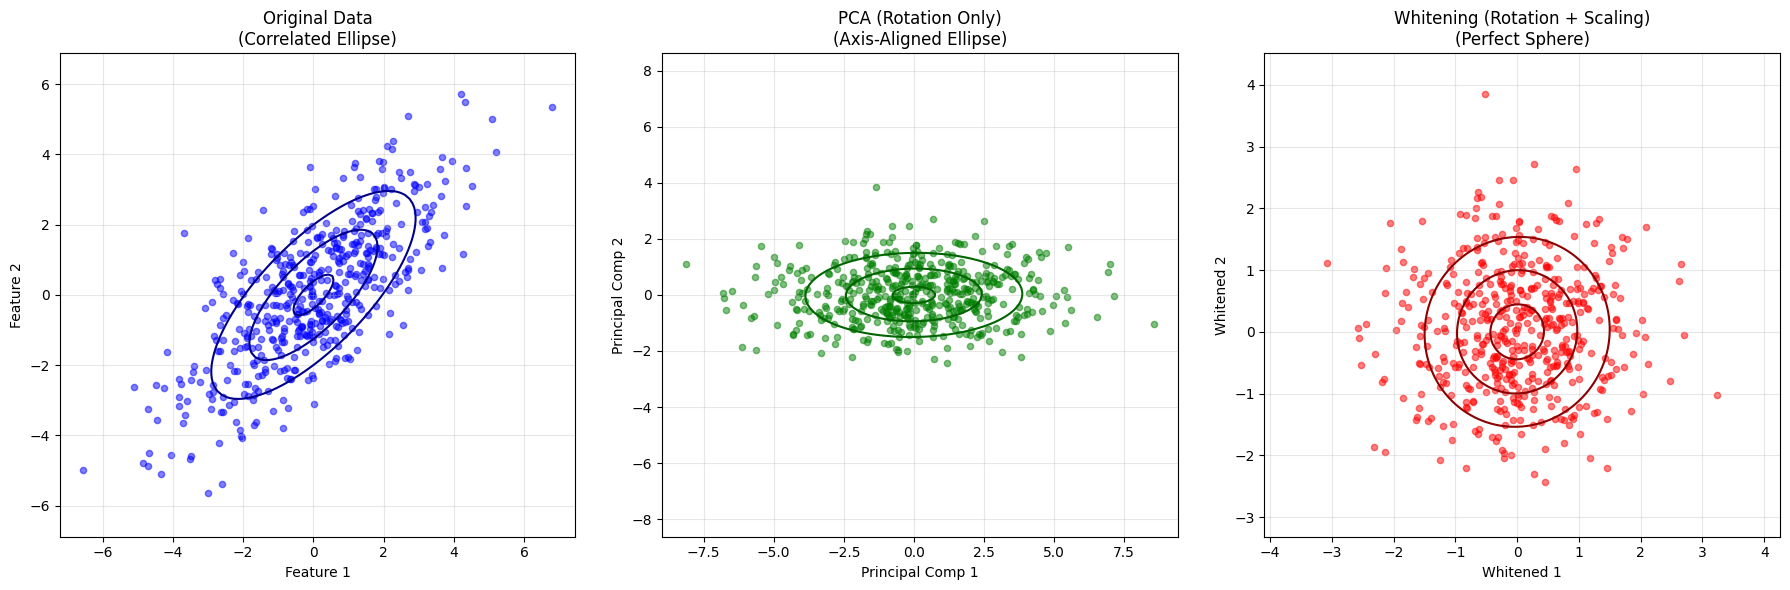


Distance Metrics for a Test Point

Test Point: [2. 1.]
Mahalanobis Distance (Original): 1.0690
Euclidean Distance (PCA Space):  2.2361
Euclidean Distance (White Space): 1.0690

✅ Conclusion: Only Whitening preserves Mahalanobis Distance as Euclidean Distance.


In [94]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

np.random.seed(42)

# ============================================================================
# 1. GENERATE CORRELATED DATA
# ============================================================================
mean = np.array([0, 0])
cov_original = np.array([[4, 3], [3, 4]])  # Correlated data
n_samples = 500
data_original = np.random.multivariate_normal(mean, cov_original, n_samples)
# print(f"Original data shape: {data_original.shape}")  # (500, 2)

# ============================================================================
# 2. PREPARE TRANSFORMATIONS
# ============================================================================
eigenvalues, eigenvectors = np.linalg.eigh(cov_original)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# PCA Transformation (Rotation Only)
# Correct: Keep shape (n_samples, n_features)
data_pca = (data_original - mean) @ eigenvectors

# Whitening Transformation (Rotation + Scaling)
scale_factors = 1.0 / np.sqrt(eigenvalues)
data_whitened = data_pca @ np.diag(scale_factors)

# print(f"PCA data shape: {data_pca.shape}")  # (500, 2)
# print(f"Whitened data shape: {data_whitened.shape}")  # (500, 2)

# ============================================================================
# 3. COMPUTE COVARIANCES
# ============================================================================
cov_original_computed = np.cov(data_original, rowvar=False)
cov_pca = np.cov(data_pca, rowvar=False)
cov_white = np.cov(data_whitened, rowvar=False)

# print(f"\nCovariance shapes:")
# print(f"Original: {cov_original_computed.shape}")  # (2, 2)
# print(f"PCA: {cov_pca.shape}")  # (2, 2)
# print(f"Whitened: {cov_white.shape}")  # (2, 2)

# ============================================================================
# 4. VISUALIZATION
# ============================================================================
print("\n" + "=" * 70)
print("COMPARISON: Original → PCA → Whitening")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plot 1: Original ---
axes[0].scatter(data_original[:, 0], data_original[:, 1], alpha=0.5, s=20, color='blue')
x, y = np.mgrid[-6:6:100j, -6:6:100j]
pos = np.dstack((x, y))
axes[0].contour(x, y, multivariate_normal(mean, cov_original_computed).pdf(pos), levels=3, colors='darkblue')
axes[0].set_title('Original Data\n(Correlated Ellipse)')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3); axes[0].axis('equal')

# --- Plot 2: PCA (Rotation Only) ---
axes[1].scatter(data_pca[:, 0], data_pca[:, 1], alpha=0.5, s=20, color='green')
x, y = np.mgrid[-5:5:100j, -5:5:100j]
pos = np.dstack((x, y))
axes[1].contour(x, y, multivariate_normal(np.zeros(2), cov_pca).pdf(pos), levels=3, colors='darkgreen')
axes[1].set_title('PCA (Rotation Only)\n(Axis-Aligned Ellipse)')
axes[1].set_xlabel('Principal Comp 1'); axes[1].set_ylabel('Principal Comp 2')
axes[1].grid(True, alpha=0.3); axes[1].axis('equal')

# --- Plot 3: Whitening (Rotation + Scaling) ---
axes[2].scatter(data_whitened[:, 0], data_whitened[:, 1], alpha=0.5, s=20, color='red')
x, y = np.mgrid[-3:3:100j, -3:3:100j]
pos = np.dstack((x, y))
axes[2].contour(x, y, multivariate_normal(np.zeros(2), cov_white).pdf(pos), levels=3, colors='darkred')
axes[2].set_title('Whitening (Rotation + Scaling)\n(Perfect Sphere)')
axes[2].set_xlabel('Whitened 1'); axes[2].set_ylabel('Whitened 2')
axes[2].grid(True, alpha=0.3); axes[2].axis('equal')

plt.tight_layout()
plt.show()

# ============================================================================
# 5. DISTANCE COMPARISON
# ============================================================================
print("\n" + "=" * 70)
print("Distance Metrics for a Test Point")
print("=" * 70)

test_point = np.array([2.0, 1.0])
inv_cov = np.linalg.inv(cov_original)
mahal_dist = np.sqrt((test_point - mean) @ inv_cov @ (test_point - mean))

# Euclidean in PCA space
test_pca = (test_point - mean) @ eigenvectors
euclid_pca = np.linalg.norm(test_pca)

# Euclidean in Whitened space
test_white = test_pca @ np.diag(scale_factors)
euclid_white = np.linalg.norm(test_white)

print(f"\nTest Point: {test_point}")
print(f"Mahalanobis Distance (Original): {mahal_dist:.4f}")
print(f"Euclidean Distance (PCA Space):  {euclid_pca:.4f}")
print(f"Euclidean Distance (White Space): {euclid_white:.4f}")

print(f"\n✅ Conclusion: Only Whitening preserves Mahalanobis Distance as Euclidean Distance.")


### Why This Matters for Mahalanobis Distance

1.  **PCA** aligns the data with the principal axes but **preserves the different variances** along those axes. If you measure Euclidean distance in PCA space, a point 2 units away along a high-variance axis is treated the same as a point 2 units away along a low-variance axis. This distorts the statistical probability.
2.  **Whitening** normalizes the variances. In this space, **1 unit equals 1 standard deviation** in every direction. Therefore, Euclidean distance in whitened space correctly represents the statistical "surprise" (Mahalanobis distance) of a point.


## Conclusion

The **Mahalanobis distance** is the natural generalization of the Z-score to multivariate dimensions. By incorporating the covariance matrix, it provides a statistically valid measure of distance that accounts for feature scales and correlations. This makes it indispensable for:
*   **Anomaly Detection:** Identifying points that are statistically unlikely.
*   **Classification:** Bayesian decision boundaries rely on this distance metric.
*   **Preprocessing:** Whitening transforms data to simplify downstream algorithms (e.g., PCA, Neural Networks).

---

##  Key Takeaways

*   **Euclidean Distance** assumes spherical data; **Mahalanobis Distance** assumes elliptical data.
*   The **Covariance Matrix** $\boldsymbol{\Sigma}$ captures the shape, scale, and orientation of the data distribution.
*   **Whitening** transforms $\boldsymbol{\Sigma}$ to $\mathbf{I}$, effectively "spherifying" the data cloud.
*   **Linear Transformation Property:** If $\mathbf{y} = W^{\top}(\mathbf{x}-\boldsymbol{\mu})$, then $\operatorname{Cov}(\mathbf{y}) = W^{\top}\boldsymbol{\Sigma}W$.
*   In the **Whitened Space**, Euclidean distance equals Mahalanobis distance.

---

## References

{cite}`Duda2000`

Duda, R. O., Hart, P. E., & Stork, D. G. (2000). *Pattern Classification* (2nd ed.). Wiley-Interscience.